<a href="https://colab.research.google.com/github/OuhmadMohamed/DI_Bootcamp/blob/main/Week4/Day2/Daily_challenge_W4_D2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Daily Challenge:** Analyzing the IMDB Movie Dataset with Matplotlib and Seaborn


1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

2. Load and Inspect Data

In [2]:
# Load dataset
df = pd.read_csv("imdb_top_1000.csv")

# First rows
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
df.shape

(1000, 16)

In [5]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


Check Missing Values

In [6]:
df.isnull().sum()

,0
Poster_Link,0
Series_Title,0
Released_Year,0
Certificate,101
Runtime,0
Genre,0
IMDB_Rating,0
Overview,0
Meta_score,157
Director,0


3. Data Preprocessing
Clean Released Year

Sometimes the year column contains non-numeric values.

In [7]:
df['Released_Year'] = pd.to_numeric(
    df['Released_Year'],
    errors='coerce'
)

Clean Gross Column

The Gross column often contains commas.

In [8]:
df['Gross'] = (
    df['Gross']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['Gross'] = pd.to_numeric(
    df['Gross'],
    errors='coerce'
)

Convert Runtime to Numeric

In [9]:
df['Runtime'] = (
    df['Runtime']
    .str.replace(' min', '')
    .astype(int)
)

Handle Missing Values

In [10]:
df['Meta_score'] = df['Meta_score'].fillna(
    df['Meta_score'].median()
)

df['Gross'] = df['Gross'].fillna(
    df['Gross'].median()
)

df['Released_Year'] = df['Released_Year'].fillna(
    df['Released_Year'].median()
)

4. Rating Trends Over Years
Average Rating per Year

In [11]:
yearly_ratings = (
    df.groupby('Released_Year')['IMDB_Rating']
    .mean()
    .reset_index()
)

Line Plot

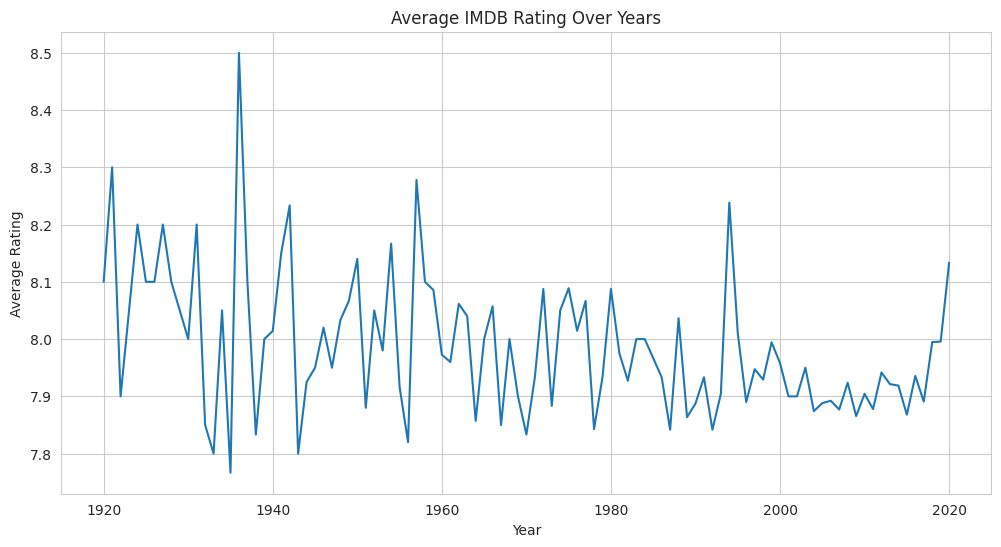

In [12]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_ratings['Released_Year'],
    yearly_ratings['IMDB_Rating']
)

plt.title("Average IMDB Rating Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.show()

Insight
Shows how movie quality (based on ratings) evolved over time.
Can identify periods with consistently high-rated films

5. Genre Popularity Analysis

Movies often contain multiple genres.

Use only the first genre for simplicity.

In [13]:
df['Main_Genre'] = (
    df['Genre']
    .str.split(',')
    .str[0]
    .str.strip()
)

Count Movies by Genre

In [14]:
genre_counts = (
    df['Main_Genre']
    .value_counts()
)

Bar Plot

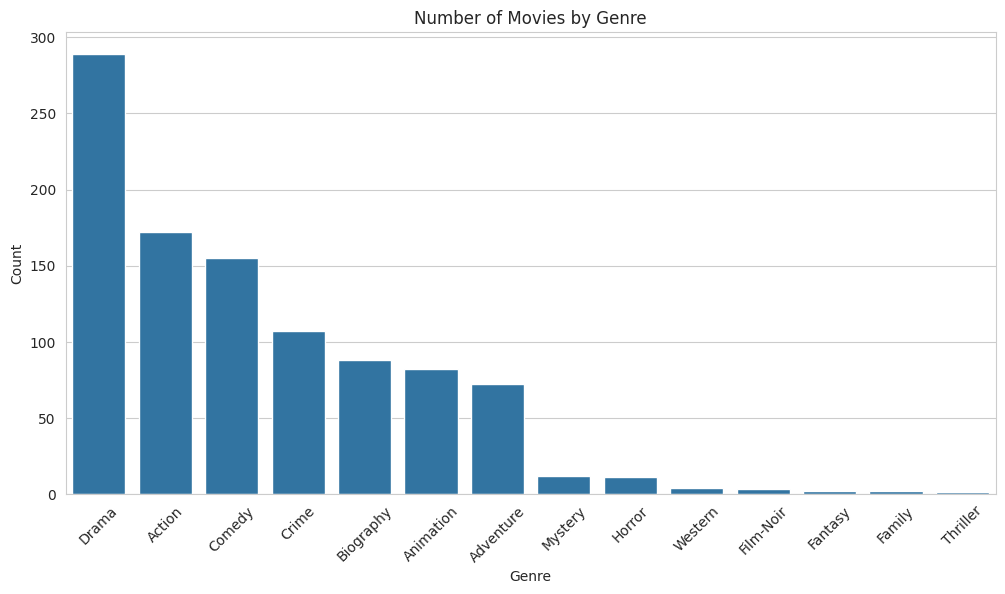

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_counts.index,
    y=genre_counts.values
)

plt.xticks(rotation=45)

plt.title("Number of Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

Insight

Identify the most represented genres in the Top 1000 IMDB movies.

6. Director's Impact on Ratings

Top Directors by Number of Movies

In [16]:
top_directors = (
    df['Director']
    .value_counts()
    .head(20)
    .index
)

In [17]:
director_df = df[
    df['Director'].isin(top_directors)
]

Scatter Plot

In [ ]:
plt.figure(figsize=(14,6))

plt.scatter(
    director_df['Director'],
    director_df['IMDB_Rating']
)

plt.xticks(rotation=90)

plt.title("Director vs IMDB Rating")
plt.xlabel("Director")
plt.ylabel("IMDB Rating")

plt.show()

Insight

Observe which directors consistently produce highly rated films.

7. Star Power Analysis

We'll use:

IMDB_Rating
Gross
No_of_Votes

Select Numerical Features

In [18]:
star_analysis = df[
    [
        'IMDB_Rating',
        'Gross',
        'No_of_Votes'
    ]
]

Pairplot

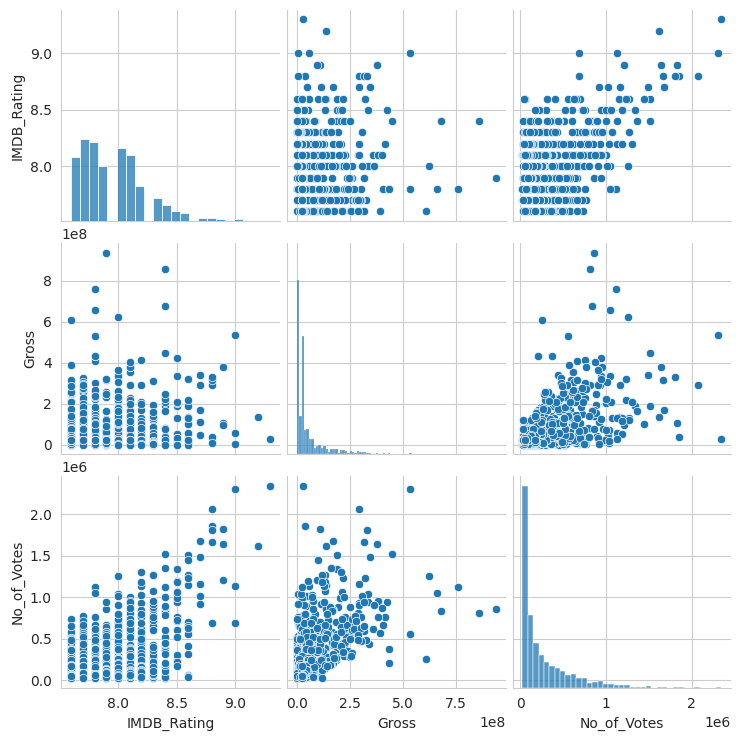

In [19]:
sns.pairplot(star_analysis)

plt.show()

nsight

Look for relationships between:

*   Votes and Ratings

*   Gross Revenue and Ratings
*   Gross Revenue and Popularity


8. Top Stars by Average Rating

Star1 Performance

In [20]:
top_stars = (
    df.groupby('Star1')['IMDB_Rating']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

Visualization

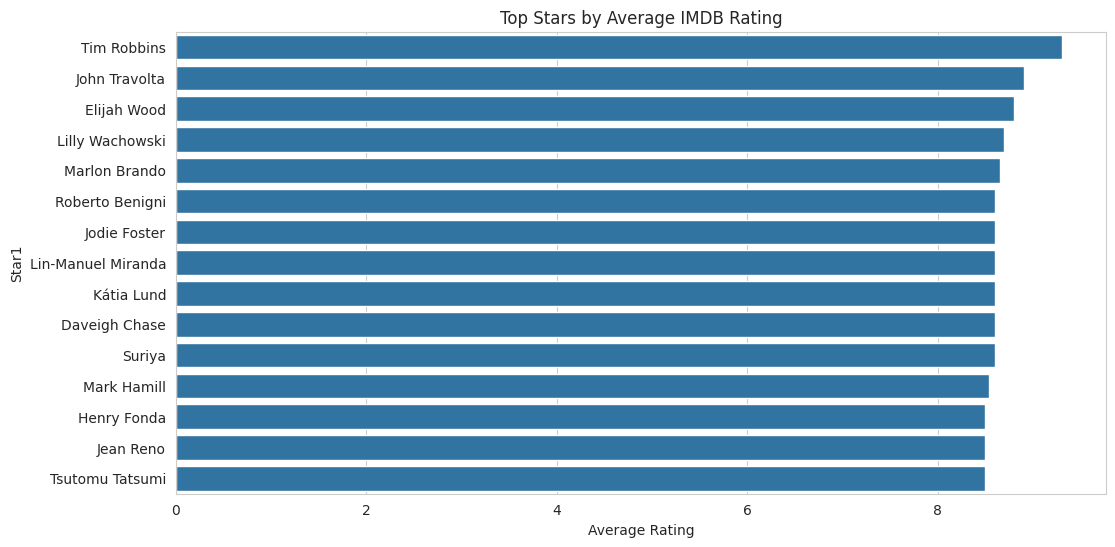

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_stars.values,
    y=top_stars.index
)

plt.title("Top Stars by Average IMDB Rating")
plt.xlabel("Average Rating")

plt.show()

9. Box Plot of Genres vs Ratings

Top Genres

In [22]:
top_genres = (
    df['Main_Genre']
    .value_counts()
    .head(10)
    .index
)

genre_df = df[
    df['Main_Genre'].isin(top_genres)
]

Box Plot

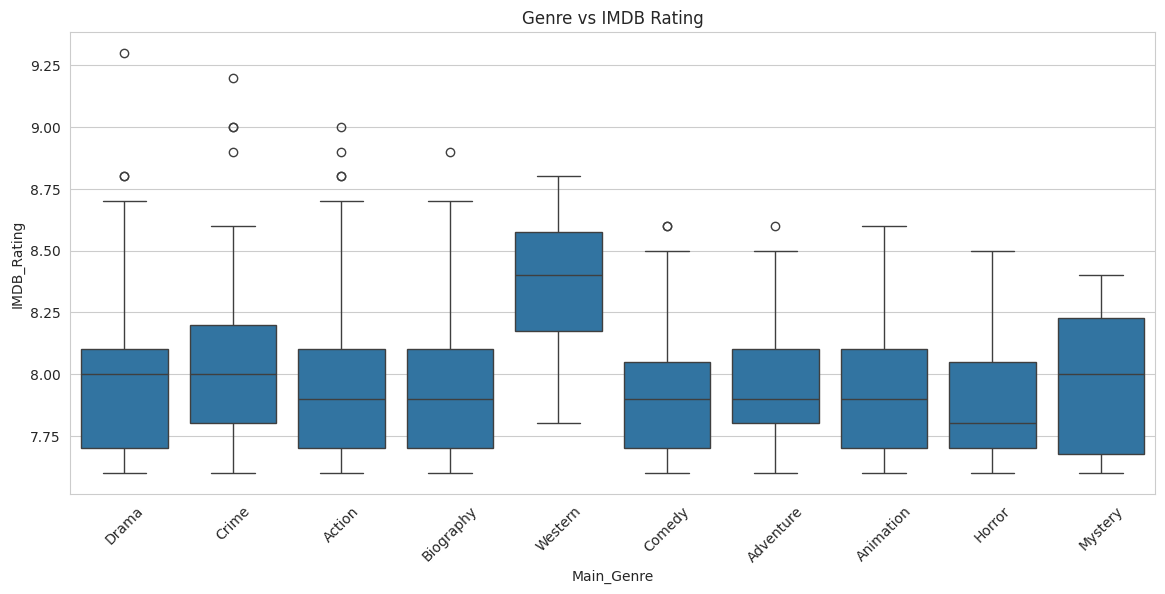

In [23]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='Main_Genre',
    y='IMDB_Rating',
    data=genre_df
)

plt.xticks(rotation=45)

plt.title("Genre vs IMDB Rating")

plt.show()

Insight

Shows:

* Median rating
* Rating variability
* Outliers

for each genre.

10. Correlation Heatmap

Select Numerical Columns

In [24]:
numerical_cols = [
    'IMDB_Rating',
    'Meta_score',
    'No_of_Votes',
    'Gross',
    'Runtime'
]

In [25]:
corr = df[numerical_cols].corr()

Heatmap

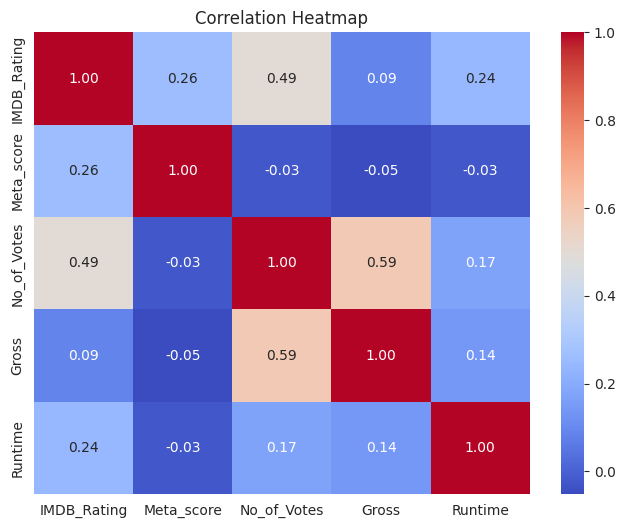

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

Insight

Look for relationships such as:

* IMDB_Rating ↔ Meta_score
* Gross ↔ No_of_Votes
* Runtime ↔ Rating

11. Bonus: Top 10 Highest Grossing Movies

In [27]:
top_gross = (
    df[['Series_Title','Gross']]
    .sort_values('Gross', ascending=False)
    .head(10)
)

In [28]:
top_gross = (
    df[['Series_Title','Gross']]
    .sort_values('Gross', ascending=False)
    .head(10)
)

12. Bonus: Ratings Distribution

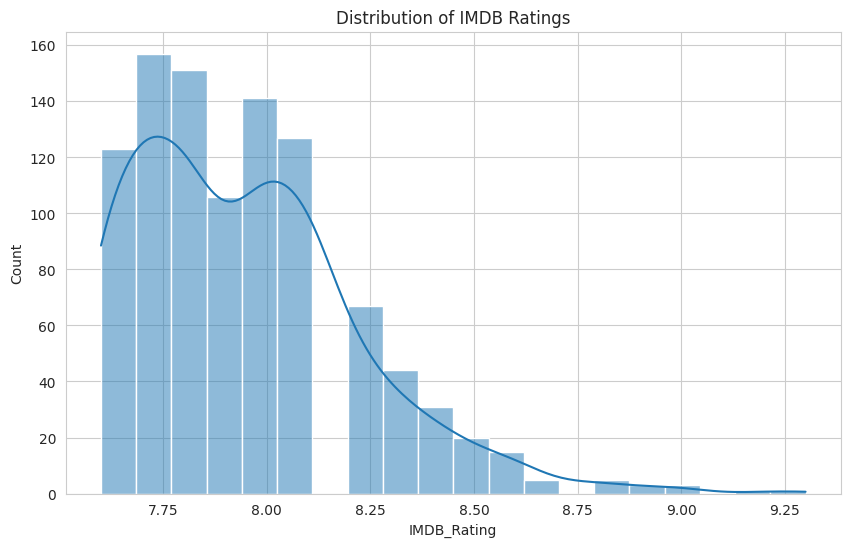

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['IMDB_Rating'],
    bins=20,
    kde=True
)

plt.title("Distribution of IMDB Ratings")

plt.show()